# Assignment 7: Mall Customer Segmentation
### Unsupervised Learning with K-Means Clustering & PCA

**Source:** [Mall Customer Segmentation Dataset](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python) (Kaggle)

This notebook segments mall customers into meaningful groups using K-Means clustering, determines
the optimal number of clusters with the Elbow Method, visualizes the segments using PCA, profiles
each cluster with a business-friendly name, and recommends strategies for each segment.


## 0. Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 6)
RANDOM_STATE = 42

df = pd.read_csv("Mall_Customers.csv")
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Quick Structural Check

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [4]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


There are **no missing values** and **no duplicate records** in this dataset, so no
imputation or deduplication is required.


### Quick Look at Feature Distributions

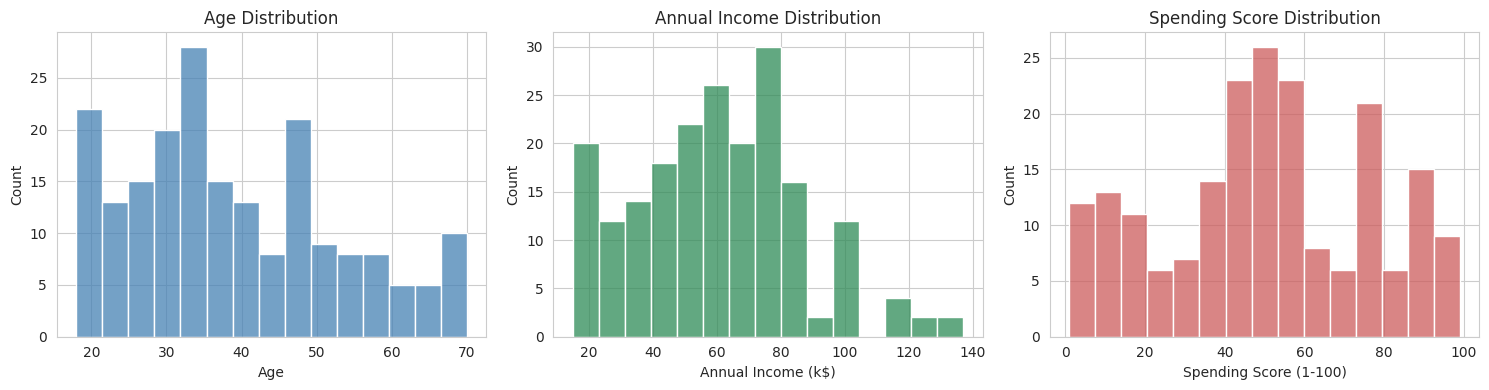

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["Age"], bins=15, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution")
sns.histplot(df["Annual Income (k$)"], bins=15, ax=axes[1], color="seagreen")
axes[1].set_title("Annual Income Distribution")
sns.histplot(df["Spending Score (1-100)"], bins=15, ax=axes[2], color="indianred")
axes[2].set_title("Spending Score Distribution")
plt.tight_layout()
plt.show()

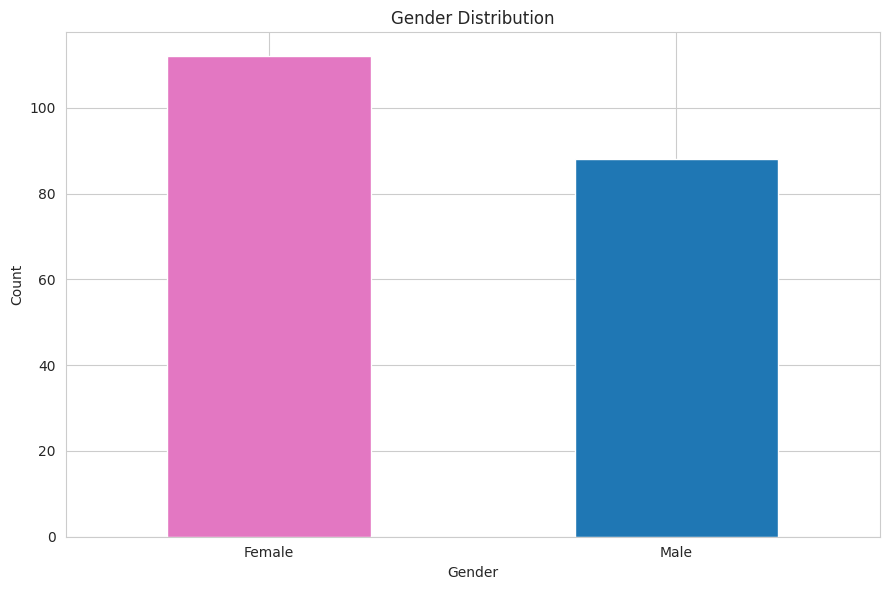

In [6]:
df["Gender"].value_counts().plot(kind="bar", color=["#e377c2", "#1f77b4"])
plt.title("Gender Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Part 1: Data Preparation

### Encode Categorical Features

`Gender` is the only categorical feature. We encode it numerically (`Male` = 0, `Female` = 1) so
it can optionally be included in clustering, though our primary clustering uses the two most
behaviorally meaningful numeric features (see below).


In [7]:
df["Gender_encoded"] = df["Gender"].map({"Male": 0, "Female": 1})
df[["Gender", "Gender_encoded"]].drop_duplicates()

,Gender,Gender_encoded
0,Male,0
2,Female,1


### Feature Selection for Clustering

We cluster on **`Annual Income (k$)`** and **`Spending Score (1-100)`** — these two features
directly capture *purchasing power* and *purchasing behavior*, which is exactly what a mall
wants to segment customers by for targeted marketing. `CustomerID` is an identifier (not a
feature), and `Age`/`Gender` are examined separately below to profile the resulting clusters
without diluting the primary segmentation signal.


In [8]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### Feature Scaling — Why It Matters for K-Means

K-Means assigns points to clusters based on **Euclidean distance** to each cluster's centroid.
If features are left on their original scales, a feature with a naturally larger numeric range
(here, `Annual Income (k$)`, roughly 15-137) would dominate the distance calculation over a
feature with a smaller range (`Spending Score`, 1-100) purely because of its scale — not because
it's actually more important. `StandardScaler` transforms each feature to have mean 0 and
standard deviation 1, so both features contribute proportionally to the clustering, regardless of
their original units or ranges.


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling (mean, std):")
print(X.mean().values, X.std().values)
print("\nAfter scaling (mean, std):")
print(X_scaled.mean(axis=0).round(4), X_scaled.std(axis=0).round(4))

Before scaling (mean, std):
[60.56 50.2 ] [26.26472117 25.82352167]

After scaling (mean, std):
[-0. -0.] [1. 1.]


## Part 2: Build the Clustering Model

### Elbow Method — Choosing the Optimal Number of Clusters

We fit K-Means for k = 1 to 10 and plot each model's inertia (within-cluster sum of squared
distances). The "elbow" — the point where adding more clusters stops meaningfully reducing
inertia — indicates a good choice for k.


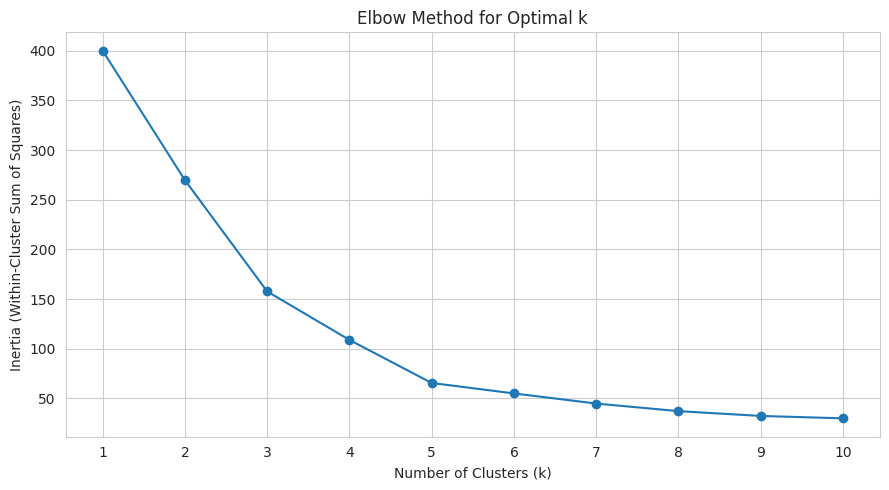

k=1: inertia=400.0
k=2: inertia=269.7
k=3: inertia=157.7
k=4: inertia=108.9
k=5: inertia=65.6
k=6: inertia=55.1
k=7: inertia=44.9
k=8: inertia=37.2
k=9: inertia=32.4
k=10: inertia=30.0


In [10]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertias, marker="o", color="#1f77b4")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

for k, inertia in zip(k_range, inertias):
    print(f"k={k}: inertia={inertia:.1f}")

**Elbow interpretation:** inertia drops sharply from k=1 through k=5, then flattens out
noticeably from k=5 onward (the marginal reduction per additional cluster becomes much smaller).
This makes **k=5** the clear elbow point and our chosen number of clusters.


### Train the Final K-Means Model (k=5)

In [11]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df["Cluster"].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

### Cluster Profiles (Mean Feature Values per Cluster)

In [12]:
cluster_profile = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
cluster_profile["Count"] = df["Cluster"].value_counts().sort_index()
cluster_profile["Female %"] = (df.groupby("Cluster")["Gender_encoded"].mean() * 100).round(1)
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Count,Female %
Cluster,,,,,
0,42.7,55.3,49.5,81,59.3
1,32.7,86.5,82.1,39,53.8
2,25.3,25.7,79.4,22,59.1
3,41.1,88.2,17.1,35,45.7
4,45.2,26.3,20.9,23,60.9


### Visualize Clusters on the Original Feature Space (Income vs. Spending Score)

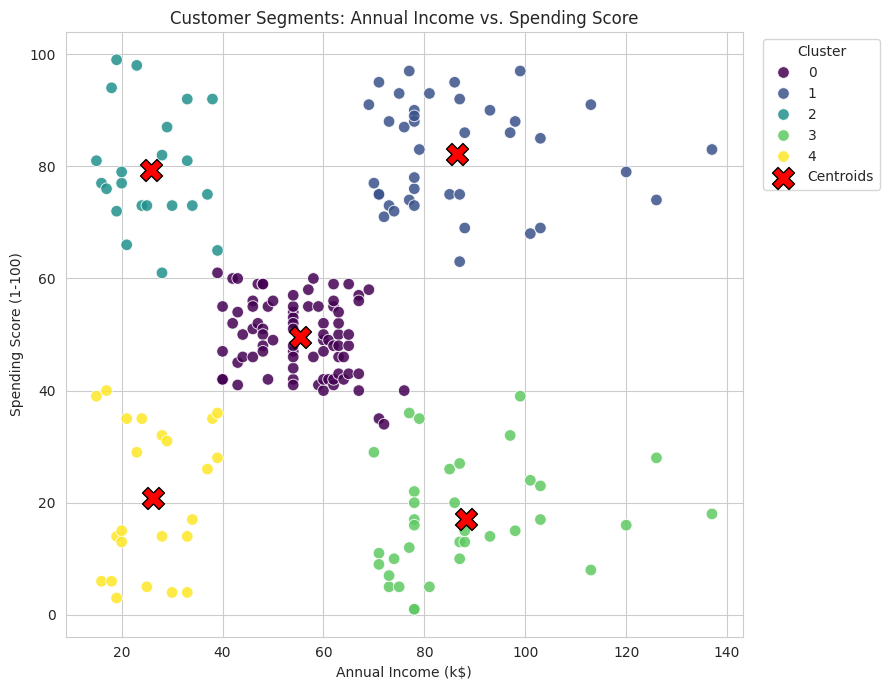

In [13]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Cluster",
                 palette="viridis", s=70, alpha=0.85)

centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], marker="X", s=250,
            color="red", edgecolor="black", label="Centroids")

plt.title("Customer Segments: Annual Income vs. Spending Score")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Naming the Clusters

Based on each cluster's average income and spending score, we assign a meaningful business name:


In [14]:
# Names are assigned by inspecting cluster_profile above and matching income/spending patterns
cluster_names = {}
for cluster_id, row in cluster_profile.iterrows():
    income, spending = row["Annual Income (k$)"], row["Spending Score (1-100)"]
    if income >= 70 and spending >= 60:
        name = "Premium Spenders"
    elif income >= 70 and spending < 60:
        name = "Cautious High Earners"
    elif income < 45 and spending >= 60:
        name = "Aspirational Spenders"
    elif income < 45 and spending < 45:
        name = "Budget-Conscious"
    else:
        name = "Average / Balanced"
    cluster_names[cluster_id] = name

df["Segment"] = df["Cluster"].map(cluster_names)
cluster_profile["Segment Name"] = cluster_profile.index.map(cluster_names)
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Count,Female %,Segment Name
Cluster,,,,,,
0,42.7,55.3,49.5,81,59.3,Average / Balanced
1,32.7,86.5,82.1,39,53.8,Premium Spenders
2,25.3,25.7,79.4,22,59.1,Aspirational Spenders
3,41.1,88.2,17.1,35,45.7,Cautious High Earners
4,45.2,26.3,20.9,23,60.9,Budget-Conscious


## Part 3: Visualize the Results with PCA

Although we clustered on just 2 features (already visualizable directly), the assignment asks us
to apply PCA to reduce the data to 2 dimensions and report explained variance — so we run PCA
across a **richer feature set** (`Age`, `Annual Income`, `Spending Score`) to demonstrate
dimensionality reduction meaningfully, then visualize the same cluster assignments in this PCA
space.


In [15]:
pca_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X_pca_input = StandardScaler().fit_transform(df[pca_features])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_pca_input)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

explained = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained[0]*100:.1f}%")
print(f"Variance explained by PC2: {explained[1]*100:.1f}%")
print(f"Total variance explained by both components: {explained.sum()*100:.1f}%")

Variance explained by PC1: 44.3%
Variance explained by PC2: 33.3%
Total variance explained by both components: 77.6%


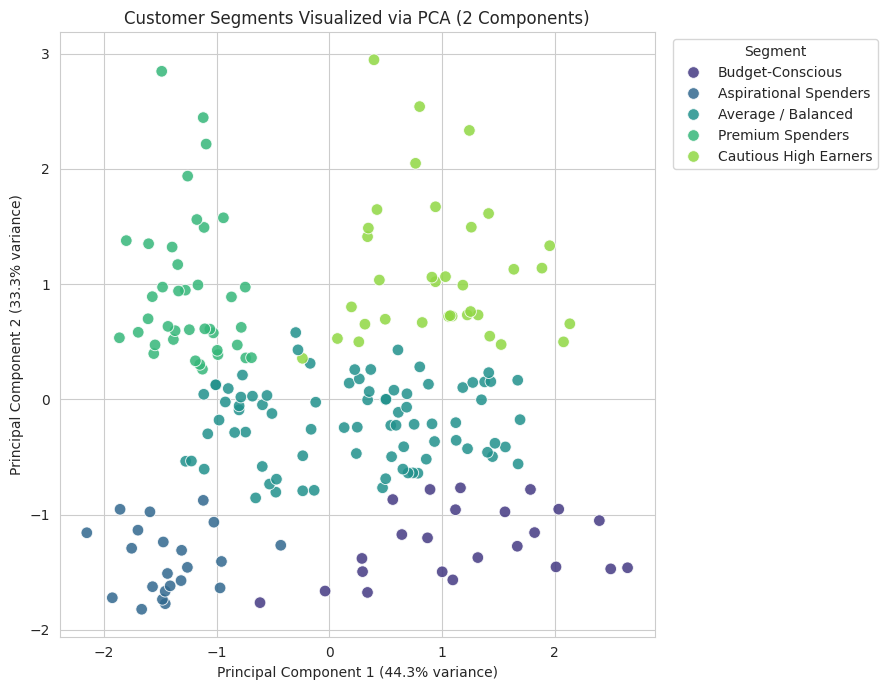

In [16]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="Segment", palette="viridis", s=70, alpha=0.85)
plt.title("Customer Segments Visualized via PCA (2 Components)")
plt.xlabel(f"Principal Component 1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({explained[1]*100:.1f}% variance)")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [17]:
# Component loadings — how much each original feature contributes to PC1 and PC2
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=pca_features)
loadings

,PC1,PC2
Age,0.706382,0.030141
Annual Income (k$),-0.048024,0.998832
Spending Score (1-100),-0.706199,-0.037775


**PCA interpretation:** together, the two principal components explain **77.6%** of the total
variance in `Age`, `Annual Income`, and `Spending Score` (PC1: 44.3%, PC2: 33.3%). Looking at the
loadings, **PC1** is driven almost entirely by `Age` and `Spending Score` (loadings of 0.71 and
-0.71 — moving in opposite directions), making it primarily an "age vs. spending behavior" axis,
while **PC2** is driven almost entirely by `Annual Income` (loading of 0.999). This means the 2D
PCA plot separates customers along two largely independent axes: how their spending relates to
their age (PC1), and how much they earn (PC2) — and since our clusters were built directly on
income and spending score, they remain visually well-separated across this PCA projection too.


## Part 4: Business Insights & Segment Strategies



In [18]:
summary = cluster_profile[["Segment Name", "Count", "Age", "Annual Income (k$)",
                            "Spending Score (1-100)", "Female %"]].sort_values("Segment Name")
summary

,Segment Name,Count,Age,Annual Income (k$),Spending Score (1-100),Female %
Cluster,,,,,,
2,Aspirational Spenders,22,25.3,25.7,79.4,59.1
0,Average / Balanced,81,42.7,55.3,49.5,59.3
4,Budget-Conscious,23,45.2,26.3,20.9,60.9
3,Cautious High Earners,35,41.1,88.2,17.1,45.7
1,Premium Spenders,39,32.7,86.5,82.1,53.8


### Segment Profiles & Recommended Strategies

1. **Premium Spenders** (high income, high spending score) — the mall's most valuable segment:
   they earn well *and* spend freely. **Strategy:** VIP loyalty programs, early access to new
   collections/sales, and premium in-mall experiences (personal shopping, exclusive events) to
   maximize retention and lifetime value.

2. **Cautious High Earners** (high income, low spending score) — customers with strong purchasing
   power who aren't currently converting that into mall spending. **Strategy:** targeted
   promotions and curated recommendations to understand and address what's holding them back —
   they represent the highest-upside opportunity segment if engagement can be improved.

3. **Aspirational Spenders** (low income, high spending score) — customers who spend
   enthusiastically relative to their income. **Strategy:** flexible payment options (installment
   plans, store credit), loyalty point programs, and mid-range product lines that reward their
   engagement without over-extending them financially.

4. **Budget-Conscious** (low income, low spending score) — price-sensitive customers making
   minimal purchases. **Strategy:** value-focused promotions, discount events, and budget product
   lines; this segment is less likely to respond profitably to premium marketing spend.

5. **Average / Balanced** (moderate income, moderate spending score) — the "typical" mall
   customer, without a strong distinguishing pattern. **Strategy:** broad, general seasonal
   marketing and loyalty programs; monitor this segment over time, as individual customers may
   drift toward one of the more distinctive segments as their circumstances change.


## Conclusions

- **K-Means with k=5** (chosen via the Elbow Method) cleanly separates mall customers into five
  visually and behaviorally distinct segments based on `Annual Income` and `Spending Score`.
- **Feature scaling was essential** — without it, `Annual Income`'s larger numeric range would
  have dominated distance calculations and distorted the clusters.
- **PCA confirms the segmentation is meaningful** even in a richer 3-feature space (including
  `Age`), with income and spending score driving the primary axis of separation.
- The resulting segments map directly onto **actionable retention and marketing strategies**,
  rather than being abstract statistical groupings — from VIP treatment for Premium Spenders to
  value-focused promotions for the Budget-Conscious segment.
